# **Prétraitement**

In [1]:
# =========================================================
# CELLULE 1 — Setup unique (remplace TOUT le début)
# =========================================================
import os, re, glob, random, sys
import numpy as np
import pandas as pd
import librosa
import librosa.display
import scipy.signal as signal
import soundfile as sf
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Audio, display

# ── Paths — UNE SEULE FOIS ───────────────────────────
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from config import (
    DATA_DIR, SPLIT_FILE, RES_DIR,
    TARGET_SR, TARGET_LEN, TARGET_SEC,
    N_MELS, N_FFT, HOP_LENGTH, FMIN, FMAX,
    NUM_CLASSES, RARE_CLASSES,
    USE_MIXUP, USE_SPECAUGMENT,
    P_PITCH, P_MIXUP, LABEL_NAMES,
)

# Forcer Path sur tous les dossiers
DATA_DIR = Path(DATA_DIR)
RES_DIR  = Path(RES_DIR)
OUT_DIR  = PROJECT_ROOT / "data" / "preprocessed"
FIG_DIR  = PROJECT_ROOT / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP         = {(0,0):0, (1,0):1, (0,1):2, (1,1):3}
AST_TARGET_LENGTH = 251
colors            = ['#1D9E75','#378ADD','#7F77DD','#D4537E']

# ── Vérification types ────────────────────────────────
print(f"PROJECT_ROOT : {PROJECT_ROOT} — {type(PROJECT_ROOT)}")
print(f"OUT_DIR      : {OUT_DIR} — {type(OUT_DIR)}")
print(f"FIG_DIR      : {FIG_DIR} — {type(FIG_DIR)}")
print(f"RES_DIR      : {RES_DIR} — {type(RES_DIR)}")

Device : cuda
PROJECT_ROOT : D:\projet DL — <class 'pathlib.WindowsPath'>
OUT_DIR      : D:\projet DL\data\preprocessed — <class 'pathlib.WindowsPath'>
FIG_DIR      : D:\projet DL\figures — <class 'pathlib.WindowsPath'>
RES_DIR      : D:\projet DL\results — <class 'pathlib.WindowsPath'>


In [2]:
METADATA_FILE = os.path.join(RES_DIR, "metadata.csv")
df = pd.read_csv(METADATA_FILE)

# =========================================================
# OFFICIAL ICBHI SPLIT
# =========================================================
split_df = pd.read_csv(
    SPLIT_FILE,
    sep=r"\s+",
    names=["filename", "split"],
    engine="python",
    encoding="utf-8-sig"
)

split_df["filename"] = split_df["filename"].astype(str).str.strip()
split_df["split"] = split_df["split"].astype(str).str.strip()

df["filename"] = df["filename"].astype(str).str.strip()

df["filename_clean"] = df["filename"].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)
split_df["filename_clean"] = split_df["filename"].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

split_map = dict(zip(split_df["filename_clean"], split_df["split"]))
df["split"] = df["filename_clean"].map(split_map)

df_train = df[df["split"] == "train"].reset_index(drop=True)
df_test = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train : {len(df_train)} cycles")
print(f"Test  : {len(df_test)} cycles")

if "label_name" in df_train.columns:
    print("\nRépartition des classes dans train :")
    print(df_train["label_name"].value_counts())
else:
    print("\nRépartition des labels dans train :")
    print(df_train["label"].value_counts())

Train : 4131 cycles
Test  : 2756 cycles

Répartition des classes dans train :
label_name
Normal     2057
Crackle    1210
Wheeze      501
Both        363
Name: count, dtype: int64


In [3]:
# ── SpecAugment ───────────────────────────────────────
freq_mask = T.FrequencyMasking(freq_mask_param=20)
time_mask = T.TimeMasking(time_mask_param=30)

# ── Audio utils ───────────────────────────────────────
def cyclic_pad(wav, target_len):
    if wav is None or len(wav) == 0:
        return np.zeros(target_len, dtype=np.float32)
    if len(wav) >= target_len:
        return wav[:target_len].astype(np.float32)
    return np.tile(wav, target_len // len(wav) + 1)[:target_len].astype(np.float32)

def zscore_normalize(audio):
    std = np.std(audio)
    if std < 1e-8:
        return np.zeros_like(audio, dtype=np.float32)
    audio = (audio - np.mean(audio)) / (std + 1e-8)
    return (np.clip(audio, -3.0, 3.0) / 3.0).astype(np.float32)

def one_hot(label, num_classes=NUM_CLASSES):
    y = np.zeros(num_classes, dtype=np.float32)
    y[int(label)] = 1.0
    return y

def load_raw_cycle(row):
    start    = float(row["start"])
    duration = float(row["end"] - row["start"]) \
               if "end" in row.index and pd.notna(row["end"]) \
               else float(row["cycle_dur"])
    if duration <= 0:
        return np.zeros(1, dtype=np.float32)
    audio, _ = librosa.load(
        row["wav_path"], sr=TARGET_SR,
        offset=start, duration=duration
    )
    return audio.astype(np.float32)

def audio_to_mel(audio):
    mel = librosa.feature.melspectrogram(
        y=audio, sr=TARGET_SR, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS,
        fmin=FMIN, fmax=FMAX, power=2.0
    )
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)

def mixup_audio(x1, y1, x2, y2, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    return (lam*x1+(1-lam)*x2).astype(np.float32), \
           (lam*y1+(1-lam)*y2).astype(np.float32)

# ── Nouvelles fonctions amélioration ─────────────────
def bandpass_filter(audio, sr=16000, low=50, high=2000):
    nyq = sr / 2
    b, a = signal.butter(4, [low/nyq, high/nyq], btype='band')
    try:
        return signal.filtfilt(b, a, audio).astype(np.float32)
    except:
        return audio

def filter_short_cycles(df, min_dur=0.5):
    before = len(df)
    df = df[df['cycle_dur'] >= min_dur].reset_index(drop=True)
    print(f"  Supprimés (< {min_dur}s) : {before - len(df)}")
    return df

def oversample_rare(df):
    targets = {'Both': 900, 'Wheeze': 1200}
    rows = []
    for label_name, target in targets.items():
        subset = df[df['label_name'] == label_name]
        needed = target - len(subset)
        if needed <= 0:
            continue
        print(f"  {label_name} : {len(subset)} → {target} (+{needed})")
        for i in range(needed):
            row = subset.iloc[i % len(subset)].copy()
            row['pitch_steps'] = int(np.random.choice([-2, -1, 1, 2]))
            rows.append(row)
    df = df.copy()
    df['pitch_steps'] = 0
    result = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)
    return result

print("Fonctions prétraitement définies ✓")

Fonctions prétraitement définies ✓


In [4]:
def precompute_v2(df, split_name, is_train=False):
    X, Y, L = [], [], []
    errors   = 0

    for idx, row in df.iterrows():
        try:
            audio = load_raw_cycle(row)

            if is_train and row.get('pitch_steps', 0) != 0:
                audio = librosa.effects.pitch_shift(
                    audio, sr=TARGET_SR,
                    n_steps=int(row['pitch_steps'])
                )

            if len(audio) > 100:
                audio = bandpass_filter(audio)

            audio = cyclic_pad(audio, TARGET_LEN)
            audio = zscore_normalize(audio)
            mel   = audio_to_mel(audio)

            X.append(mel)
            Y.append(one_hot(int(row["label"])))
            L.append(int(row["label"]))

        except Exception as e:
            errors += 1
            continue

        if idx % 300 == 0:
            print(f"  {split_name} : {idx}/{len(df)}...")

    np.savez_compressed(
        OUT_DIR / f"{split_name}.npz",
        X=np.array(X, dtype=np.float32),
        Y=np.array(Y, dtype=np.float32),
        L=np.array(L, dtype=np.int32)
    )
    print(f"✓ {split_name}.npz — {len(X)} samples | erreurs: {errors}")
    print(f"  Distribution : {np.bincount(np.array(L))}")

# ── Lancer dans l'ordre ───────────────────────────────
print("ÉTAPE 1 — Filtrage cycles courts")
df_train_clean = filter_short_cycles(df_train)
df_test_clean  = filter_short_cycles(df_test)

print("\nÉTAPE 2 — Oversampling train")
df_train_aug = oversample_rare(df_train_clean)
print(df_train_aug['label_name'].value_counts())

print("\nÉTAPE 3 — Precompute train")
precompute_v2(df_train_aug, "train", is_train=True)

print("\nÉTAPE 4 — Precompute test")
precompute_v2(df_test_clean, "test", is_train=False)

print("\n✓ Terminé → python train.py")

ÉTAPE 1 — Filtrage cycles courts
  Supprimés (< 0.5s) : 29
  Supprimés (< 0.5s) : 12

ÉTAPE 2 — Oversampling train
  Both : 363 → 900 (+537)


  Wheeze : 499 → 1200 (+701)


label_name
Normal     2031
Crackle    1209
Wheeze     1200
Both        900
Name: count, dtype: int64

ÉTAPE 3 — Precompute train


D:\projet DL\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  train : 0/5340...


...

  test : 1800/2744...


  test : 2100/2744...


  test : 2400/2744...


  test : 2700/2744...


✓ test.npz — 2744 samples | erreurs: 0
  Distribution : [1571  647  383  143]

✓ Terminé → python train.py


APERÇU DES DONNÉES APRÈS PRÉTRAITEMENT
Train X shape : (5340, 128, 157)
Train Y shape : (5340, 4)
Train L shape : (5340,)
Test  X shape : (2744, 128, 157)
Test  Y shape : (2744, 4)
Test  L shape : (2744,)


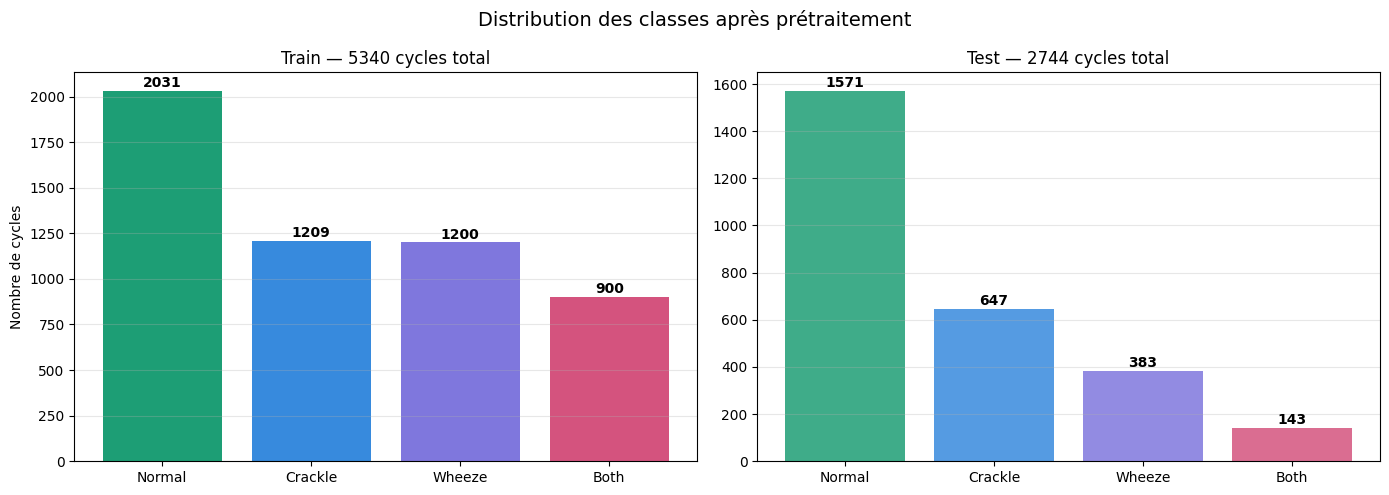


Classe          Train     %Train     Test      %Test
Normal           2031      38.0%     1571      57.3%
Crackle          1209      22.6%      647      23.6%
Wheeze           1200      22.5%      383      14.0%
Both              900      16.9%      143       5.2%
TOTAL            5340     100.0%     2744     100.0%

STATS DES SPECTROGRAMMES PAR CLASSE (train)
Classe              Min        Max       Mean        Std
----------------------------------------------------------------------


Normal           -80.00       0.00     -59.73      19.99
Crackle          -80.00       0.00     -60.41      19.17


Wheeze           -80.00       0.00     -62.05      19.18
Both             -80.00       0.00     -61.80      19.00


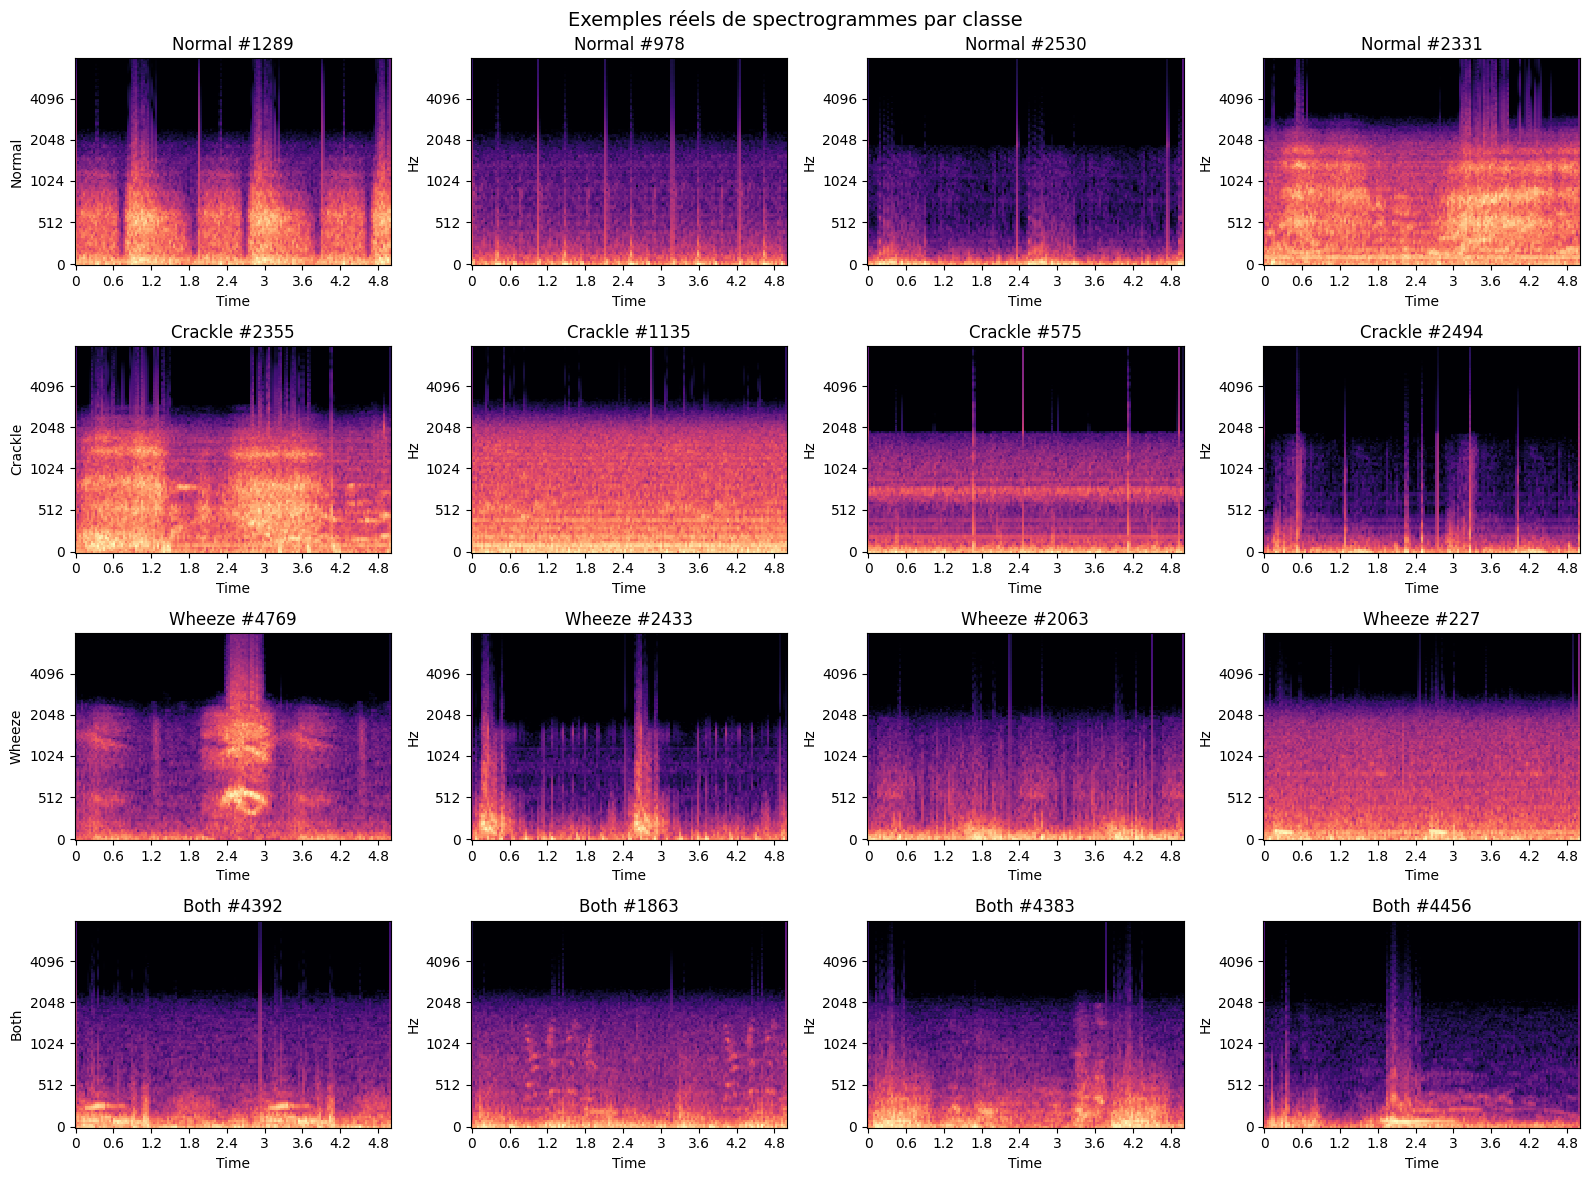

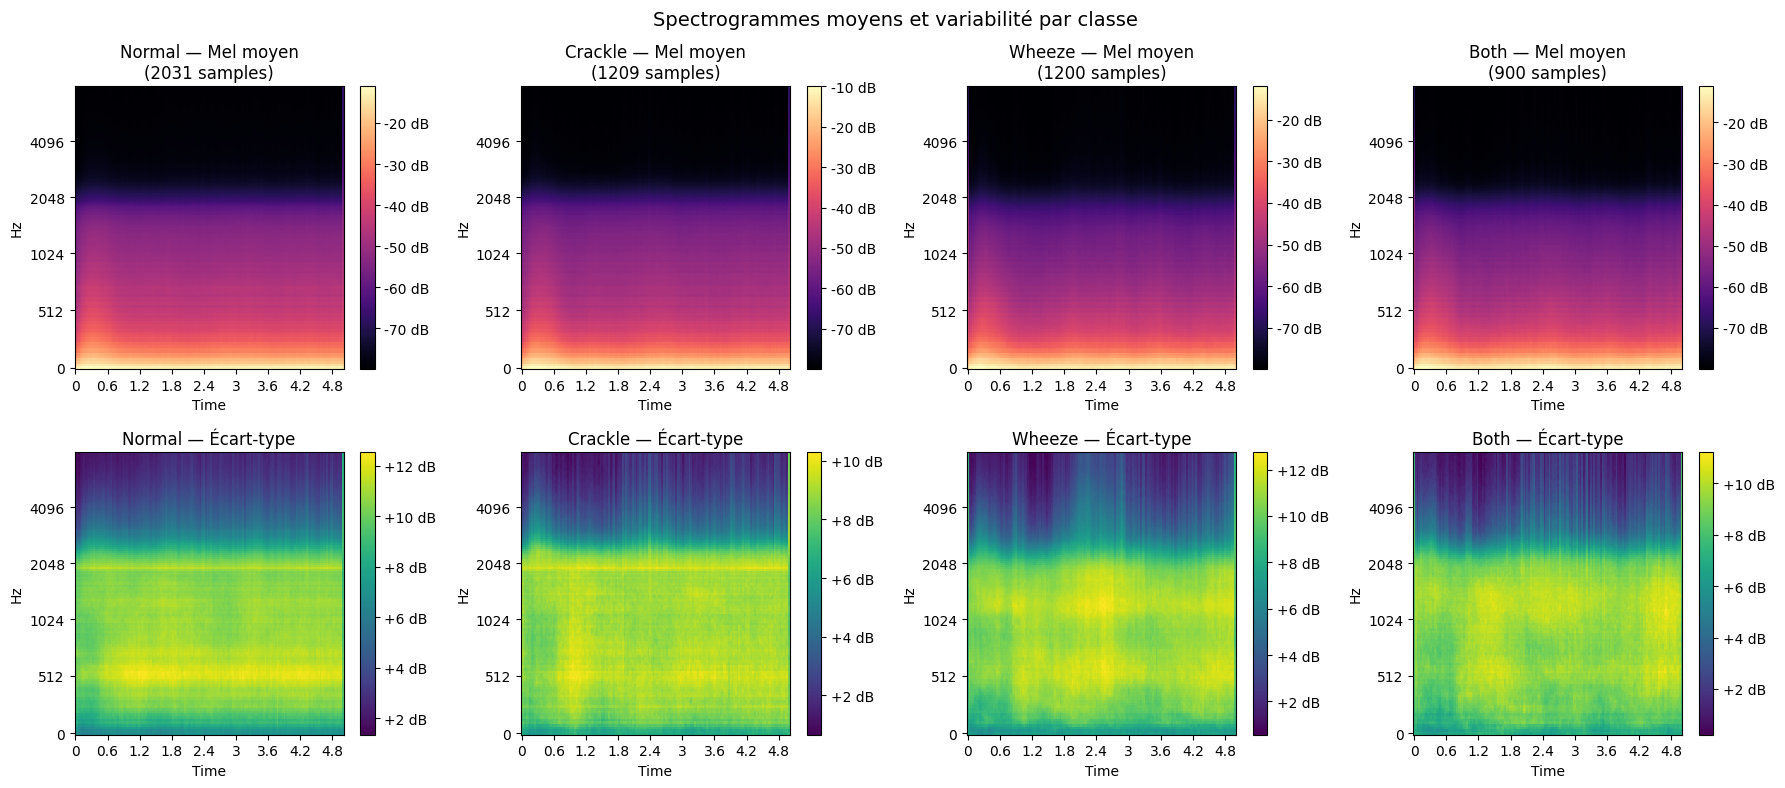

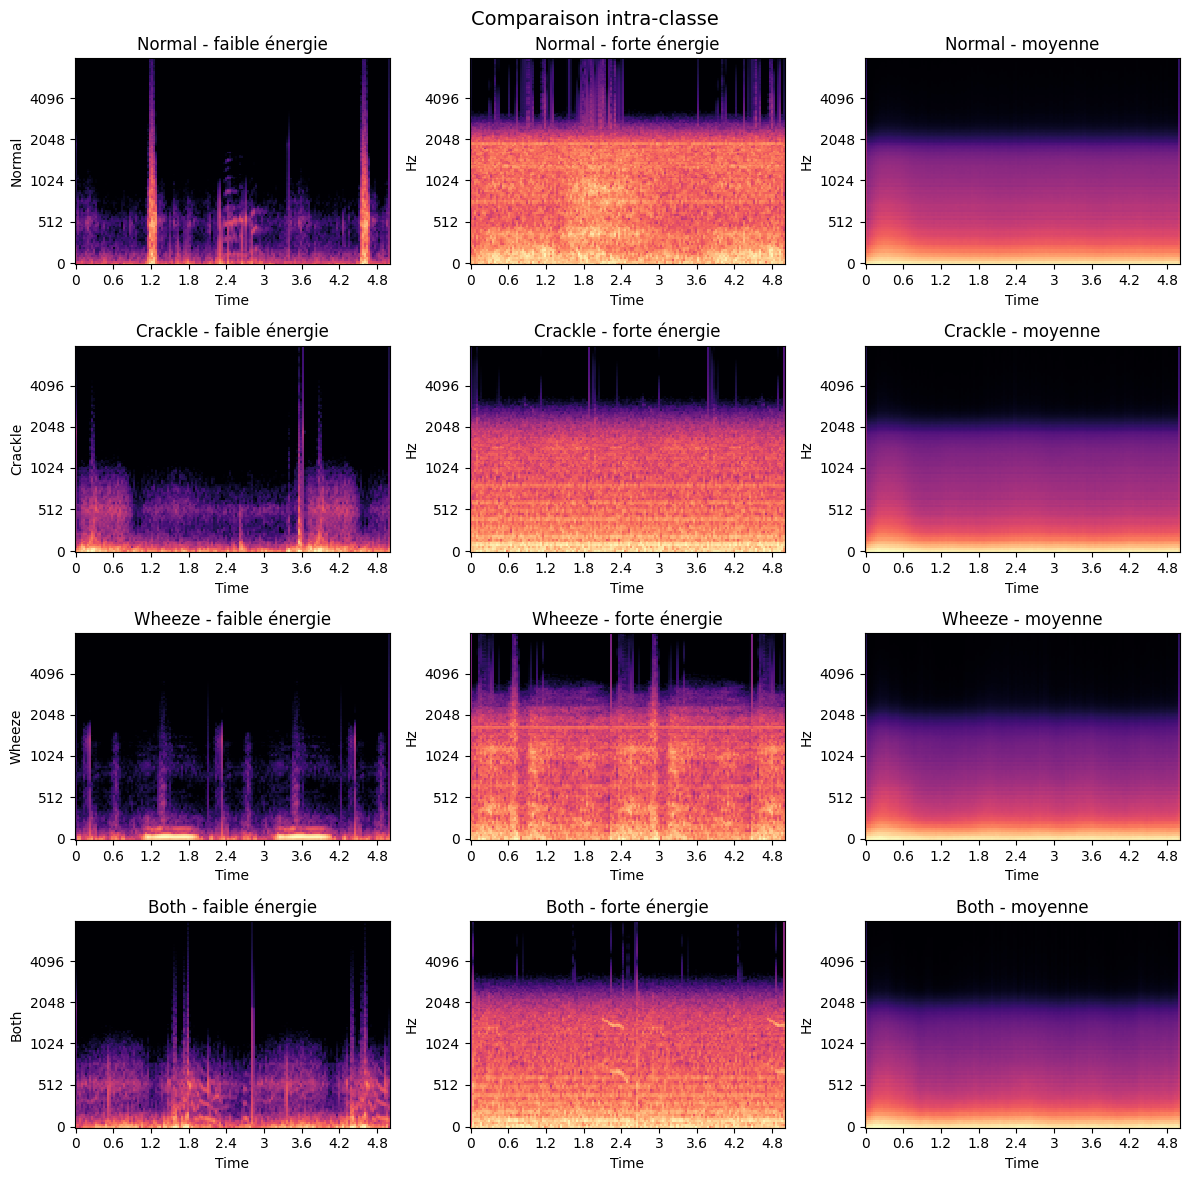

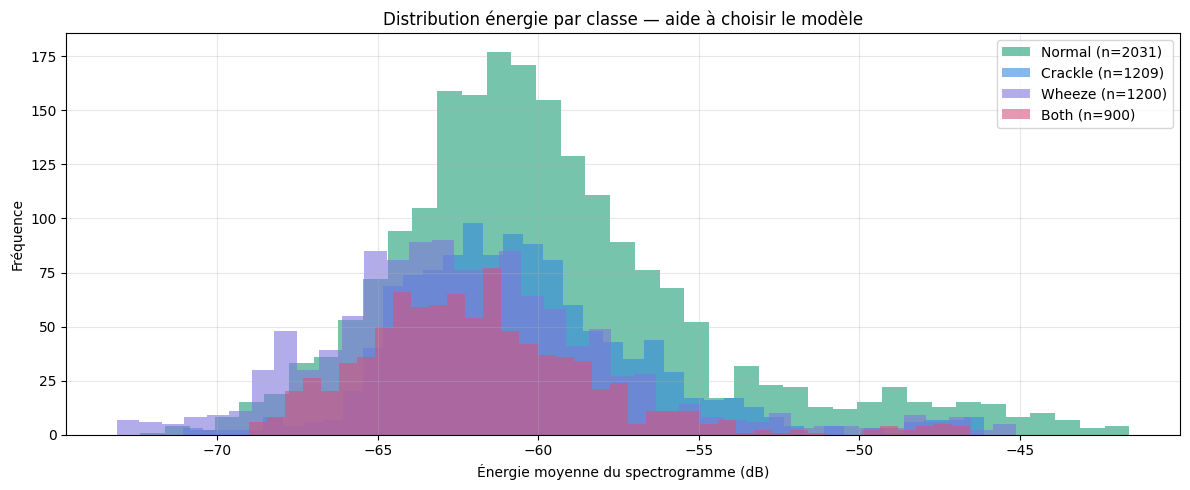

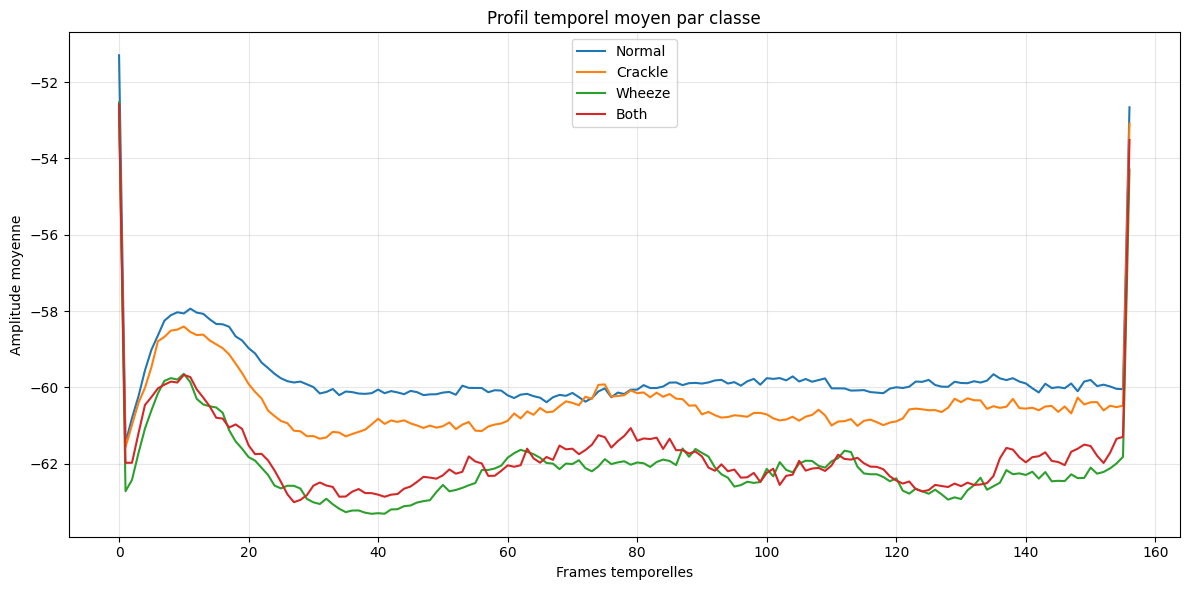

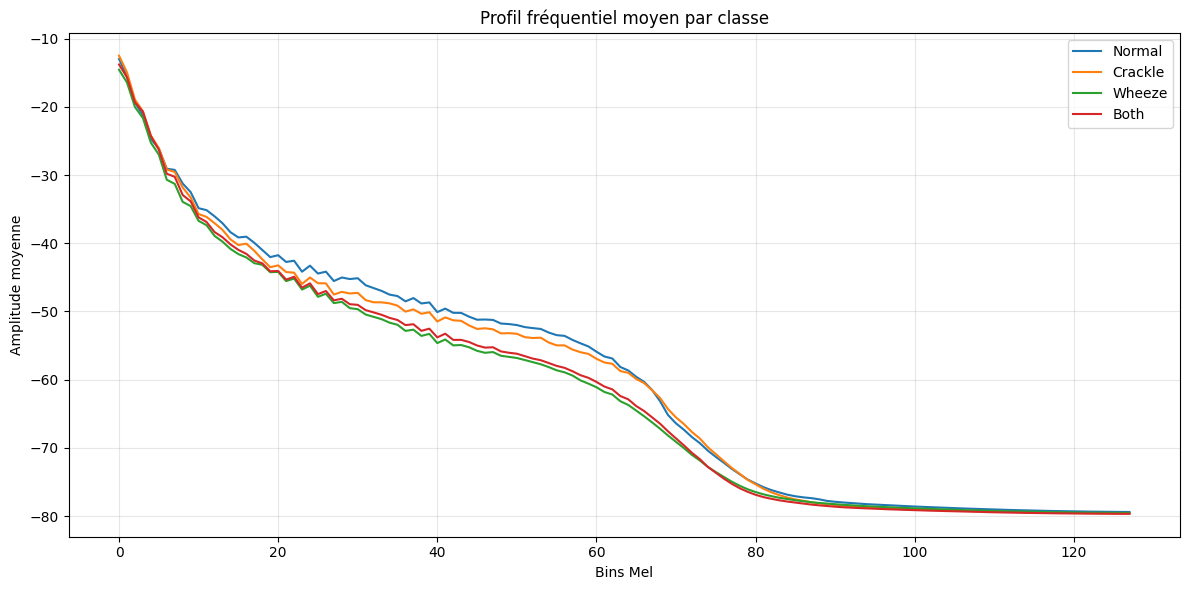


AIDE AU CHOIX DU MODÈLE
Classe          VarTemp    VarFreq      HF/LF           Suggestion


Normal            5.376     18.648     -2.189                  CNN
Crackle           4.731     18.260     -2.138                  CNN


Wheeze            5.503     17.862     -2.055                  CNN
Both              5.024     18.066     -2.091                  CNN

INTERPRÉTATION RAPIDE
- Si les classes montrent des motifs locaux assez nets -> CNN
- Si les motifs évoluent fortement dans le temps -> CNN + GRU / CRNN
- Si la structure est très complexe et globale -> Transformer/AST
- Si les classes se ressemblent beaucoup visuellement -> commencer par un CNN simple robuste

✓ Figures sauvegardées dans : D:\projet DL\figures


In [5]:
# =========================================================
# STATS ET VISUALISATIONS APRÈS PRÉTRAITEMENT
# Objectif :
# - voir ce que "voit" réellement le modèle après preprocess
# - comparer les classes
# - estimer si un CNN suffit ou si un modèle temporel est préférable
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path

# =========================================================
# CHARGEMENT DES DONNÉES PRÉTRAITÉES
# =========================================================
train_data = np.load(OUT_DIR / "train.npz")
test_data  = np.load(OUT_DIR / "test.npz")

X_train, Y_train, L_train = train_data["X"], train_data["Y"], train_data["L"]
X_test,  Y_test,  L_test  = test_data["X"],  test_data["Y"],  test_data["L"]

FIG_DIR.mkdir(parents=True, exist_ok=True)

colors = ['#1D9E75', '#378ADD', '#7F77DD', '#D4537E']

print("=" * 70)
print("APERÇU DES DONNÉES APRÈS PRÉTRAITEMENT")
print("=" * 70)
print(f"Train X shape : {X_train.shape}")
print(f"Train Y shape : {Y_train.shape}")
print(f"Train L shape : {L_train.shape}")
print(f"Test  X shape : {X_test.shape}")
print(f"Test  Y shape : {Y_test.shape}")
print(f"Test  L shape : {L_test.shape}")

# =========================================================
# STAT 1 — Distribution des classes train vs test
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = np.bincount(L_train, minlength=len(LABEL_NAMES))
test_counts  = np.bincount(L_test, minlength=len(LABEL_NAMES))

axes[0].bar(LABEL_NAMES, train_counts, color=colors)
for i, v in enumerate(train_counts):
    axes[0].text(i, v + max(5, int(0.01 * max(train_counts))), str(v),
                 ha='center', fontweight='bold')
axes[0].set_title(f'Train — {len(L_train)} cycles total')
axes[0].set_ylabel('Nombre de cycles')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(LABEL_NAMES, test_counts, color=colors, alpha=0.85)
for i, v in enumerate(test_counts):
    axes[1].text(i, v + max(3, int(0.01 * max(test_counts))), str(v),
                 ha='center', fontweight='bold')
axes[1].set_title(f'Test — {len(L_test)} cycles total')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution des classes après prétraitement', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "post_preprocess_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# =========================================================
# STAT 2 — Tableau résumé
# =========================================================
print("\n" + "=" * 70)
print(f"{'Classe':<12} {'Train':>8} {'%Train':>10} {'Test':>8} {'%Test':>10}")
print("=" * 70)

for i, name in enumerate(LABEL_NAMES):
    n_train = train_counts[i]
    n_test  = test_counts[i]
    p_train = (n_train / len(L_train) * 100) if len(L_train) else 0
    p_test  = (n_test / len(L_test) * 100) if len(L_test) else 0

    print(f"{name:<12} {n_train:>8} {p_train:>9.1f}% {n_test:>8} {p_test:>9.1f}%")

print("=" * 70)
print(f"{'TOTAL':<12} {len(L_train):>8} {'100.0%':>10} {len(L_test):>8} {'100.0%':>10}")

# =========================================================
# STAT 3 — Stats globales des spectrogrammes par classe
# =========================================================
print("\n" + "=" * 70)
print("STATS DES SPECTROGRAMMES PAR CLASSE (train)")
print("=" * 70)
print(f"{'Classe':<12} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 70)

for i, name in enumerate(LABEL_NAMES):
    idx = np.where(L_train == i)[0]
    if len(idx) == 0:
        print(f"{name:<12} {'N/A':>10} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
        continue

    subs = X_train[idx]
    print(f"{name:<12} {subs.min():>10.2f} {subs.max():>10.2f} {subs.mean():>10.2f} {subs.std():>10.2f}")

# =========================================================
# STAT 4 — Exemples réels de spectrogrammes par classe
# Important : voir des vrais samples, pas seulement la moyenne
# =========================================================
N_EXAMPLES = 4
fig, axes = plt.subplots(len(LABEL_NAMES), N_EXAMPLES, figsize=(16, 12), squeeze=False)

for i, name in enumerate(LABEL_NAMES):
    idx = np.where(L_train == i)[0]

    if len(idx) == 0:
        for j in range(N_EXAMPLES):
            axes[i, j].axis("off")
        continue

    chosen = np.random.choice(idx, size=min(N_EXAMPLES, len(idx)), replace=False)

    for j in range(N_EXAMPLES):
        ax = axes[i, j]
        if j < len(chosen):
            sample_id = chosen[j]
            librosa.display.specshow(
                X_train[sample_id],
                sr=TARGET_SR,
                hop_length=HOP_LENGTH,
                x_axis='time',
                y_axis='mel',
                cmap='magma',
                ax=ax
            )
            ax.set_title(f"{name} #{sample_id}")
            if j == 0:
                ax.set_ylabel(name)
        else:
            ax.axis("off")

plt.suptitle("Exemples réels de spectrogrammes par classe", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "real_examples_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

# =========================================================
# STAT 5 — Spectrogrammes moyens et écart-type par classe
# mean = structure moyenne
# std  = zones variables
# =========================================================
fig, axes = plt.subplots(2, len(LABEL_NAMES), figsize=(18, 8), squeeze=False)

for i, name in enumerate(LABEL_NAMES):
    idx = np.where(L_train == i)[0]

    if len(idx) == 0:
        axes[0, i].axis("off")
        axes[1, i].axis("off")
        continue

    mean_mel = X_train[idx].mean(axis=0)
    std_mel  = X_train[idx].std(axis=0)

    img1 = librosa.display.specshow(
        mean_mel,
        sr=TARGET_SR,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='mel',
        cmap='magma',
        ax=axes[0, i]
    )
    axes[0, i].set_title(f'{name} — Mel moyen\n({len(idx)} samples)')
    plt.colorbar(img1, ax=axes[0, i], format='%+2.0f dB')

    img2 = librosa.display.specshow(
        std_mel,
        sr=TARGET_SR,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='mel',
        cmap='viridis',
        ax=axes[1, i]
    )
    axes[1, i].set_title(f'{name} — Écart-type')
    plt.colorbar(img2, ax=axes[1, i], format='%+2.0f dB')

plt.suptitle('Spectrogrammes moyens et variabilité par classe', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "mean_spectrograms_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

# =========================================================
# STAT 6 — Comparaison intra-classe
# faible énergie / forte énergie / moyenne
# =========================================================
fig, axes = plt.subplots(len(LABEL_NAMES), 3, figsize=(12, 12), squeeze=False)

for i, name in enumerate(LABEL_NAMES):
    idx = np.where(L_train == i)[0]

    if len(idx) == 0:
        for j in range(3):
            axes[i, j].axis("off")
        continue

    class_samples = X_train[idx]
    energies = class_samples.mean(axis=(1, 2))

    low_idx  = idx[np.argmin(energies)]
    high_idx = idx[np.argmax(energies)]
    mean_mel = class_samples.mean(axis=0)

    # faible énergie
    librosa.display.specshow(
        X_train[low_idx],
        sr=TARGET_SR,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='mel',
        cmap='magma',
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{name} - faible énergie")
    axes[i, 0].set_ylabel(name)

    # forte énergie
    librosa.display.specshow(
        X_train[high_idx],
        sr=TARGET_SR,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='mel',
        cmap='magma',
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{name} - forte énergie")

    # moyenne
    librosa.display.specshow(
        mean_mel,
        sr=TARGET_SR,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='mel',
        cmap='magma',
        ax=axes[i, 2]
    )
    axes[i, 2].set_title(f"{name} - moyenne")

plt.suptitle("Comparaison intra-classe", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "intra_class_variability.png", dpi=150, bbox_inches="tight")
plt.show()

# =========================================================
# STAT 7 — Distribution énergie par classe
# =========================================================
fig, ax = plt.subplots(figsize=(12, 5))

for i, name in enumerate(LABEL_NAMES):
    idx = np.where(L_train == i)[0]
    if len(idx) == 0:
        continue

    energy = X_train[idx].mean(axis=(1, 2))
    ax.hist(
        energy,
        bins=40,
        alpha=0.6,
        label=f'{name} (n={len(idx)})',
        color=colors[i]
    )

ax.set_xlabel('Énergie moyenne du spectrogramme (dB)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution énergie par classe — aide à choisir le modèle')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "energy_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# =========================================================
# STAT 8 — Courbes temporelles moyennes par classe
# On moyenne sur l’axe fréquentiel pour observer l’évolution dans le temps
# =========================================================
fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(LABEL_NAMES):
    idx = np.where(L_train == i)[0]
    if len(idx) == 0:
        continue

    class_samples = X_train[idx]          # [N, F, T]
    temporal_curve = class_samples.mean(axis=1).mean(axis=0)  # moyenne freq puis batch
    ax.plot(temporal_curve, label=name)

ax.set_title("Profil temporel moyen par classe")
ax.set_xlabel("Frames temporelles")
ax.set_ylabel("Amplitude moyenne")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "temporal_profiles_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

# =========================================================
# STAT 9 — Profils fréquentiels moyens par classe
# On moyenne sur l’axe temporel pour voir où se concentre l’énergie
# =========================================================
fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(LABEL_NAMES):
    idx = np.where(L_train == i)[0]
    if len(idx) == 0:
        continue

    class_samples = X_train[idx]           # [N, F, T]
    freq_curve = class_samples.mean(axis=2).mean(axis=0)  # moyenne temps puis batch
    ax.plot(freq_curve, label=name)

ax.set_title("Profil fréquentiel moyen par classe")
ax.set_xlabel("Bins Mel")
ax.set_ylabel("Amplitude moyenne")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "frequency_profiles_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

# =========================================================
# STAT 10 — Aide au choix du modèle
# =========================================================
print("\n" + "=" * 70)
print("AIDE AU CHOIX DU MODÈLE")
print("=" * 70)
print(f"{'Classe':<12} {'VarTemp':>10} {'VarFreq':>10} {'HF/LF':>10} {'Suggestion':>20}")
print("=" * 70)

for i, name in enumerate(LABEL_NAMES):
    idx = np.where(L_train == i)[0]
    if len(idx) == 0:
        print(f"{name:<12} {'N/A':>10} {'N/A':>10} {'N/A':>10} {'N/A':>20}")
        continue

    mel = X_train[idx]  # [N, 128, 251] approx

    # Variabilité temporelle : variation au fil du temps
    var_temp = mel.std(axis=2).mean()

    # Variabilité fréquentielle : variation selon les bandes de fréquence
    var_freq = mel.std(axis=1).mean()

    # Rapport hautes / basses fréquences
    low_freq  = mel[:, :32, :].mean()
    high_freq = mel[:, 96:, :].mean()
    hf_lf_ratio = high_freq / (abs(low_freq) + 1e-8)

    # Suggestion heuristique
    if var_temp > 12 and var_freq > 10:
        suggestion = "Transformer / CRNN"
    elif var_temp > 12:
        suggestion = "GRU / LSTM / CRNN"
    else:
        suggestion = "CNN"

    print(f"{name:<12} {var_temp:>10.3f} {var_freq:>10.3f} {hf_lf_ratio:>10.3f} {suggestion:>20}")

# =========================================================
# CONCLUSION GLOBALE
# =========================================================
print("\n" + "=" * 70)
print("INTERPRÉTATION RAPIDE")
print("=" * 70)
print("- Si les classes montrent des motifs locaux assez nets -> CNN")
print("- Si les motifs évoluent fortement dans le temps -> CNN + GRU / CRNN")
print("- Si la structure est très complexe et globale -> Transformer/AST")
print("- Si les classes se ressemblent beaucoup visuellement -> commencer par un CNN simple robuste")
print(f"\n✓ Figures sauvegardées dans : {FIG_DIR}")